# EDI Segment Analysis with DTW Clustering
This notebook extracts variable-length EDI segments and clusters them using a DTW distance matrix (`N x N`, where `N` is number of selected segments).


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import euclidean

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS
from fastdtw import fastdtw

sns.set_theme(style='whitegrid')


In [2]:
# Paths
RAW_DIR = Path('/home/jhkim/NAVA/02_YOLO/data/1_Refined_Raw')
PEAK_DIR = Path('/home/jhkim/NAVA/02_YOLO/data/2_Refined_Peaks')

# Patient selection
PATIENT_ID = '03'  # ex: '03', 3, 'patient_03'; use None for all patients

# Segment method selection (choose one or more)
# Options: 'peak_to_peak', 'midpoint_to_midpoint', 'min_after_peak_to_next_min'
SEGMENT_METHODS = [
    # 'peak_to_peak',
    'midpoint_to_midpoint',
    # 'min_after_peak_to_next_min',
]

# Clustering settings
MIN_SEGMENT_LEN = 20
RANDOM_STATE = 42
NORMALIZE_SEGMENTS = False
FASTDTW_RADIUS = 5

# Evaluate candidate k values first, then choose SELECTED_N_CLUSTERS
K_CANDIDATES = list(range(1, 8))
SELECTED_N_CLUSTERS = None  # e.g. 3 after reviewing silhouette plot

# Full pairwise DTW is expensive (O(N^2) pairs)
MAX_SEGMENTS_FOR_DTW = 100  # set None to use all segments


In [3]:
def normalize_patient_id(v):
    if v is None:
        return None
    s = str(v).strip()
    m = re.search(r'(\d+)', s)
    if not m:
        raise ValueError("Invalid PATIENT_ID: {!r}. Use values like 3, '03', or 'patient_03'.".format(v))
    return f"{int(m.group(1)):02d}"


def discover_patient_pairs(raw_dir: Path, peak_dir: Path, patient_id=None):
    raw_map = {}
    for p in raw_dir.glob('*.xlsx'):
        raw_map[normalize_patient_id(p.stem)] = p

    peak_map = {}
    for p in peak_dir.glob('*.xlsx'):
        peak_map[normalize_patient_id(p.stem)] = p

    common_ids = sorted(set(raw_map).intersection(peak_map), key=lambda x: int(x))

    if patient_id is not None:
        pid = normalize_patient_id(patient_id)
        if pid not in common_ids:
            avail = ', '.join(common_ids[:10]) + (' ...' if len(common_ids) > 10 else '')
            raise ValueError(f'Patient {pid} not found in both directories. Available IDs: {avail}')
        common_ids = [pid]

    return [(pid, raw_map[pid], peak_map[pid]) for pid in common_ids]


def load_patient_data(raw_path: Path, peak_path: Path):
    raw = pd.read_excel(raw_path).rename(columns=str.lower)
    peaks = pd.read_excel(peak_path).rename(columns=str.lower)

    if 'timestamp' not in raw.columns or 'edi' not in raw.columns:
        raise ValueError(f'Unexpected raw schema in {raw_path.name}: {raw.columns.tolist()}')
    if 'timestamp' not in peaks.columns:
        raise ValueError(f'Unexpected peak schema in {peak_path.name}: {peaks.columns.tolist()}')

    raw = raw[['timestamp', 'edi']].dropna().sort_values('timestamp').reset_index(drop=True)
    peaks = peaks[['timestamp']].dropna().sort_values('timestamp').drop_duplicates().reset_index(drop=True)
    return raw, peaks


pairs = discover_patient_pairs(RAW_DIR, PEAK_DIR, PATIENT_ID)
print(f'Found {len(pairs)} matched patient(s): {[p[0] for p in pairs]}')


Found 1 matched patient(s): ['03']


In [4]:
def timestamps_to_indices(raw_ts: np.ndarray, event_ts: np.ndarray):
    idx = np.searchsorted(raw_ts, event_ts)
    idx = idx[(idx > 0) & (idx < len(raw_ts))]
    return np.unique(idx)


def segment_peak_to_peak(raw):
    ts = raw['timestamp'].to_numpy()
    pidx = timestamps_to_indices(ts, raw.attrs['peak_timestamps'])
    segments = []
    for i in range(len(pidx) - 1):
        s, e = int(pidx[i]), int(pidx[i + 1])
        if e - s >= MIN_SEGMENT_LEN:
            segments.append((s, e, 'peak_to_peak'))
    return segments


def segment_midpoint_to_midpoint(raw):
    ts = raw['timestamp'].to_numpy()
    pidx = timestamps_to_indices(ts, raw.attrs['peak_timestamps'])
    if len(pidx) < 2:
        return []

    mid = ((pidx[:-1] + pidx[1:]) / 2.0).astype(int)
    segments = []
    for i in range(len(mid) - 1):
        s, e = int(mid[i]), int(mid[i + 1])
        if e - s >= MIN_SEGMENT_LEN:
            segments.append((s, e, 'midpoint_to_midpoint'))
    return segments


def segment_min_after_peak_to_next_min_after_peak(raw):
    ts = raw['timestamp'].to_numpy()
    edi = raw['edi'].to_numpy()
    pidx = timestamps_to_indices(ts, raw.attrs['peak_timestamps'])
    if len(pidx) < 2:
        return []

    minima = []
    for i in range(len(pidx) - 1):
        left, right = int(pidx[i]), int(pidx[i + 1])
        if right <= left + 1:
            continue
        local_min = left + int(np.argmin(edi[left:right]))
        minima.append(local_min)

    minima = np.unique(np.array(minima, dtype=int))
    segments = []
    for i in range(len(minima) - 1):
        s, e = int(minima[i]), int(minima[i + 1])
        if e - s >= MIN_SEGMENT_LEN:
            segments.append((s, e, 'min_after_peak_to_next_min'))
    return segments


In [5]:
def collect_segments(patient_pairs):
    rows = []
    series_list = []

    valid_methods = {
        'peak_to_peak': segment_peak_to_peak,
        'midpoint_to_midpoint': segment_midpoint_to_midpoint,
        'min_after_peak_to_next_min': segment_min_after_peak_to_next_min_after_peak,
    }

    selected = [m for m in SEGMENT_METHODS if m in valid_methods]
    if len(selected) == 0:
        raise ValueError('SEGMENT_METHODS is empty or invalid. Use one or more valid method names.')

    for pid, raw_path, peak_path in patient_pairs:
        raw, peaks = load_patient_data(raw_path, peak_path)
        raw.attrs['peak_timestamps'] = peaks['timestamp'].to_numpy()

        all_segments = []
        for method_name in selected:
            all_segments.extend(valid_methods[method_name](raw))

        ts = raw['timestamp'].to_numpy()
        edi = raw['edi'].to_numpy()

        for seg_id, (s, e, seg_type) in enumerate(all_segments):
            x = edi[s:e].astype(float)
            if len(x) < MIN_SEGMENT_LEN:
                continue

            if NORMALIZE_SEGMENTS:
                x = (x - x.mean()) / (x.std() + 1e-8)

            rows.append({
                'patient_id': pid,
                'segment_type': seg_type,
                'segment_id': seg_id,
                'start_idx': int(s),
                'end_idx': int(e),
                'start_ts': float(ts[s]),
                'end_ts': float(ts[e - 1]),
                'length': int(e - s),
                'duration_ts': float(ts[e - 1] - ts[s]) if e - s > 1 else 0.0,
                'raw_file': raw_path.name,
                'peak_file': peak_path.name,
            })
            series_list.append(x)

    meta = pd.DataFrame(rows)
    return meta, series_list


segment_meta, segment_series = collect_segments(pairs)
print('Total segments:', len(segment_meta))
display(segment_meta.groupby('segment_type').size().rename('count').to_frame())


Total segments: 1706


,count
segment_type,
midpoint_to_midpoint,1706


In [6]:
if len(segment_series) == 0:
    raise ValueError('No segments found. Lower MIN_SEGMENT_LEN or check data.')

if MAX_SEGMENTS_FOR_DTW is not None and len(segment_series) > MAX_SEGMENTS_FOR_DTW:
    sampled_idx = np.random.default_rng(RANDOM_STATE).choice(
        len(segment_series), size=MAX_SEGMENTS_FOR_DTW, replace=False
    )
    sampled_idx = np.sort(sampled_idx)
    segment_meta = segment_meta.iloc[sampled_idx].reset_index(drop=True)
    segment_series = [segment_series[i] for i in sampled_idx]
    print(f'Sampled {MAX_SEGMENTS_FOR_DTW} segments for DTW matrix')

N = len(segment_series)
print('N segments used for DTW:', N)


Sampled 100 segments for DTW matrix
N segments used for DTW: 100


In [7]:
def dtw_distance(a: np.ndarray, b: np.ndarray, radius: int = 5) -> float:
    # fastdtw with Euclidean local distance
    dist, _ = fastdtw(a, b, radius=radius, dist=lambda x, y: euclidean([x], [y]))
    return float(dist)


def compute_dtw_distance_matrix(series_list, radius=5):
    n = len(series_list)
    M = np.zeros((n, n), dtype=float)
    for i in range(n):
        if i % 50 == 0:
            print(f'Computing row {i+1}/{n}')
        for j in range(i + 1, n):
            d = dtw_distance(series_list[i], series_list[j], radius=radius)
            M[i, j] = d
            M[j, i] = d
    return M


dist_matrix = compute_dtw_distance_matrix(segment_series, radius=FASTDTW_RADIUS)
print('Distance matrix shape:', dist_matrix.shape)


Computing row 1/100
Computing row 51/100
Distance matrix shape: (100, 100)


,k,silhouette,n_unique_labels
0,1,NaN,1
1,2,0.636671,2
2,3,0.600059,3
3,4,0.438700,4
4,5,0.412436,5
5,6,0.395398,6
6,7,0.401785,7


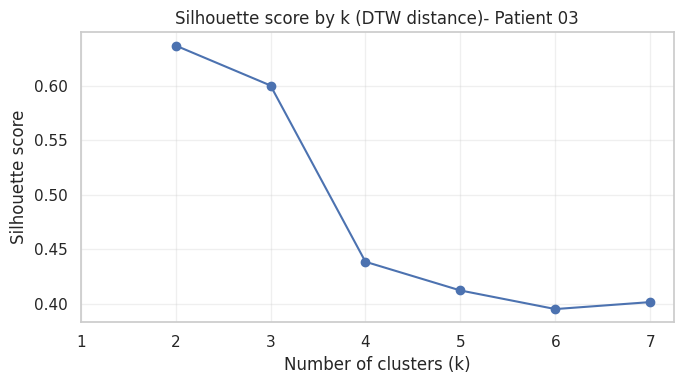

In [8]:
# 1) Try k=1..7 first and plot silhouette score
results = []
for k in K_CANDIDATES:
    if k < 1:
        continue

    clusterer_k = AgglomerativeClustering(
        n_clusters=k,
        metric='precomputed',
        linkage='average',
    )
    labels_k = clusterer_k.fit_predict(dist_matrix)
    n_unique = len(np.unique(labels_k))

    if n_unique > 1:
        sil_k = silhouette_score(dist_matrix, labels_k, metric='precomputed')
    else:
        sil_k = np.nan  # silhouette undefined for single cluster

    results.append({'k': k, 'silhouette': sil_k, 'n_unique_labels': n_unique})

silhouette_df = pd.DataFrame(results)
display(silhouette_df)

plt.figure(figsize=(7, 4))
plt.plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o')
plt.xticks(K_CANDIDATES)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title(f'Silhouette score by k (DTW distance)- Patient {PATIENT_ID if PATIENT_ID else "All Patients"}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# 2) After checking the plot, set SELECTED_N_CLUSTERS and run this cell
SELECTED_N_CLUSTERS=6
if SELECTED_N_CLUSTERS is None:
    raise ValueError('Set SELECTED_N_CLUSTERS (e.g., 3) after reviewing silhouette plot.')

if SELECTED_N_CLUSTERS < 1:
    raise ValueError('SELECTED_N_CLUSTERS must be >= 1')

clusterer = AgglomerativeClustering(
    n_clusters=SELECTED_N_CLUSTERS,
    metric='precomputed',
    linkage='average',
)
labels = clusterer.fit_predict(dist_matrix)
segment_meta['cluster'] = labels

sil = silhouette_score(dist_matrix, labels, metric='precomputed') if len(np.unique(labels)) > 1 else np.nan
print(f'N clusters: {SELECTED_N_CLUSTERS}')
print(f'Silhouette score (precomputed DTW): {sil:.4f}')

display(segment_meta.groupby('cluster').size().rename('count').to_frame())
display(pd.crosstab(segment_meta['cluster'], segment_meta['segment_type']))


N clusters: 6
Silhouette score (precomputed DTW): 0.3954


,count
cluster,
0,7
1,18
2,15
3,58
4,1
5,1


segment_type,midpoint_to_midpoint
cluster,
0,7
1,18
2,15
3,58
4,1
5,1


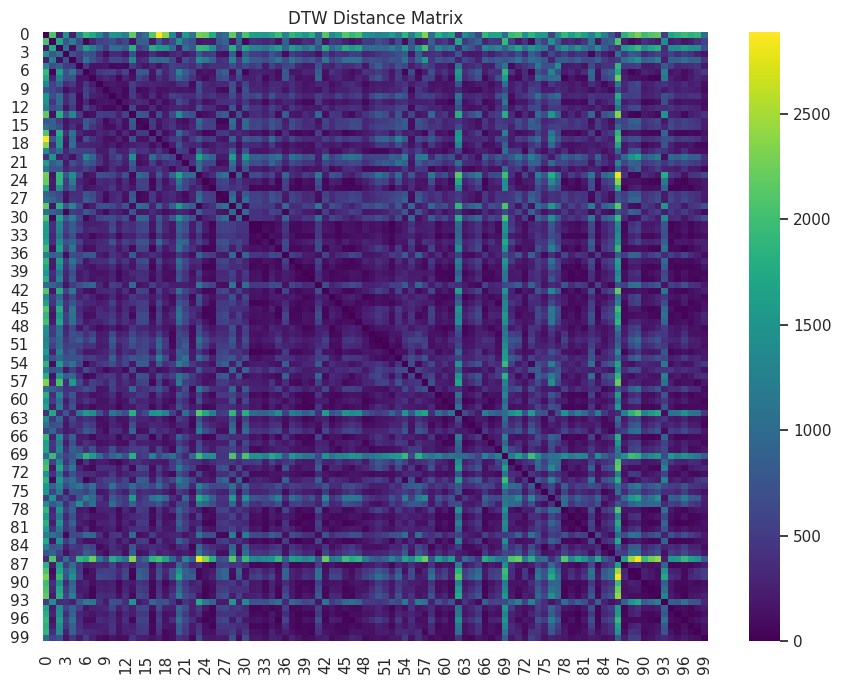

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(dist_matrix, cmap='viridis')
plt.title('DTW Distance Matrix')
plt.tight_layout()
plt.show()


/home/jhkim/miniconda3/envs/NAVA/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


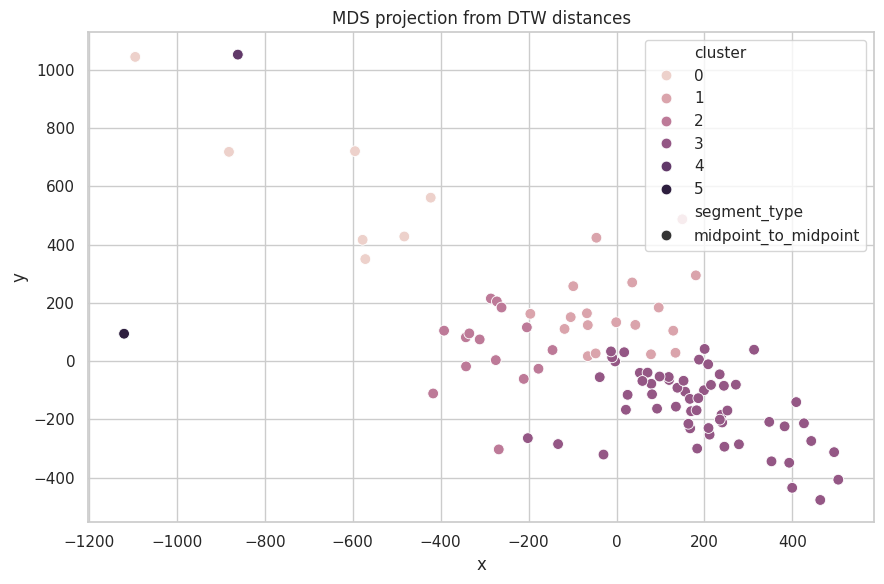

In [11]:
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_STATE)
coords = mds.fit_transform(dist_matrix)

plot_df = segment_meta.copy()
plot_df['x'] = coords[:, 0]
plot_df['y'] = coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', style='segment_type', s=60)
plt.title('MDS projection from DTW distances')
plt.tight_layout()
plt.show()


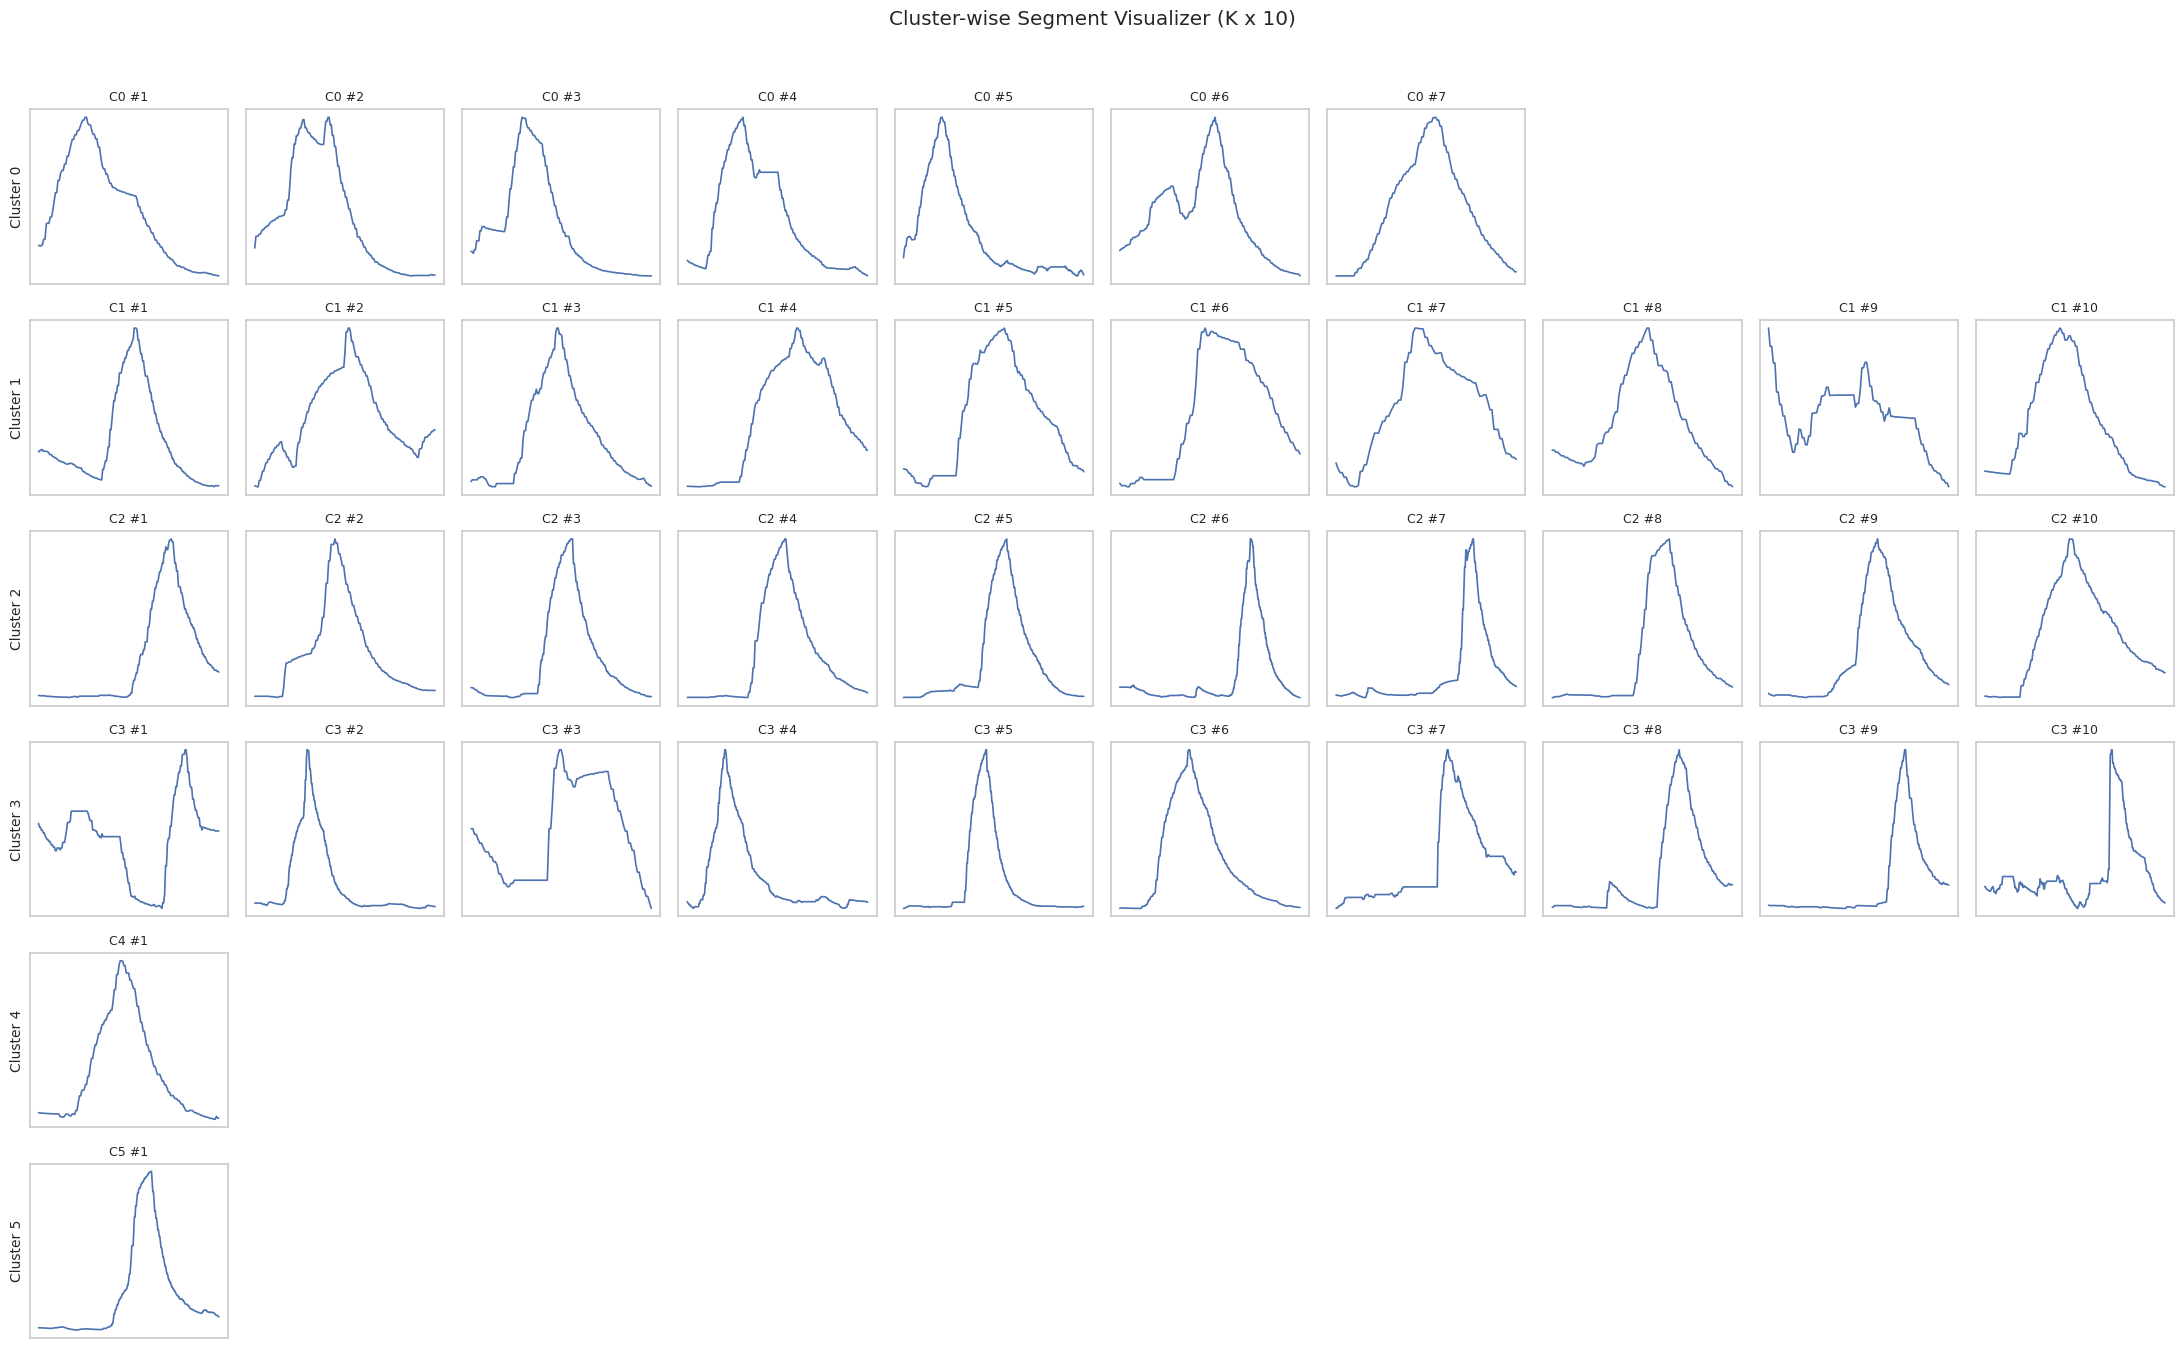

In [12]:
# Visualize up to 10 segments per cluster (K x 10 grid)
max_per_cluster = 10
clusters = sorted(segment_meta['cluster'].unique())
K = len(clusters)

fig, axes = plt.subplots(K, max_per_cluster, figsize=(2.2 * max_per_cluster, 2.2 * K), squeeze=False)

for row_i, c in enumerate(clusters):
    idx = np.where(segment_meta['cluster'].to_numpy() == c)[0]
    take = idx[:max_per_cluster]

    for col_j in range(max_per_cluster):
        ax = axes[row_i, col_j]
        if col_j < len(take):
            sidx = take[col_j]
            x = segment_series[sidx]
            ax.plot(x, lw=1.2)
            ax.set_title(f'C{c} #{col_j+1}', fontsize=9)
        else:
            ax.axis('off')

        if col_j == 0:
            ax.set_ylabel(f'Cluster {c}', fontsize=10)

        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Cluster-wise Segment Visualizer (K x 10)', y=1.02)
plt.tight_layout()
plt.show()



In [13]:
# OUT_CSV = Path('/home/jhkim/NAVA/02_YOLO/notebooks/outputs/segment_clustering_results_dtw.csv')
# OUT_NPY = Path('/home/jhkim/NAVA/02_YOLO/notebooks/outputs/segment_dtw_distance_matrix.npy')
# OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# segment_meta.to_csv(OUT_CSV, index=False)
# np.save(OUT_NPY, dist_matrix)

# print('Saved:', OUT_CSV)
# print('Saved:', OUT_NPY)
